# 4. Avaliação orientada a jogadores

Este notebook organiza uma camada de avaliação qualitativa em cima dos artefatos gerados nos notebooks anteriores. A ideia é sair do ranking agregado de condições e permitir inspeção nominal: escolher jogadores pelo nome, comparar perfis, medir proximidade entre eles e recuperar vizinhos similares de forma reproduzível.

O foco aqui não é rerodar o experimento completo do notebook 3, mas criar um arcabouço de análise para responder perguntas como:
- quais jogadores são mais próximos entre si dentro de um conjunto de features específico;
- como diferentes métricas alteram os vizinhos recomendados;
- quais atributos mais explicam a aproximação entre dois ou mais nomes selecionados.

In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"
RAW_PATH = ROOT / "data" / "merged_players (1).csv"
OUTFIELD_Z_PATH = DATA_DIR / "outfield_z.csv"
OUTFIELD_RAW_PATH = DATA_DIR / "outfield_raw.csv"
FEATURE_SETS_PATH = DATA_DIR / "feature_sets.json"
MODEL_RESULTS_TABLE_PATH = DATA_DIR / "model_selection_results.csv"
MODEL_RESULTS_SUMMARY_PATH = DATA_DIR / "model_selection_summary.json"

with open(FEATURE_SETS_PATH, "r", encoding="utf-8") as handle:
    feature_sets = json.load(handle)

FEATURE_ALIASES = {
    "technical": "T",
    "mental": "M",
    "physical": "F",
    "set_pieces": "SP",
}
METRIC_LABELS = {
    "euclidean": "Euclidiana",
    "cosine": "Cosseno",
    "pearson": "Pearson",
}
ALL_FEATURES = [column for columns in feature_sets.values() for column in columns]

if MODEL_RESULTS_SUMMARY_PATH.exists():
    with open(MODEL_RESULTS_SUMMARY_PATH, "r", encoding="utf-8") as handle:
        model_selection_summary = json.load(handle)
else:
    model_selection_summary = None

DEFAULT_FEATURE_SET_KEY = (
    model_selection_summary["feature_set_key"] if model_selection_summary else "technical"
 )
DEFAULT_METRIC = model_selection_summary["metric_key"] if model_selection_summary else "euclidean"

df_z = pd.read_csv(OUTFIELD_Z_PATH)
df_raw = pd.read_csv(OUTFIELD_RAW_PATH)
player_meta = (
    pd.read_csv(RAW_PATH, usecols=["UID", "Name", "Club", "Position", "Age"])
    .drop_duplicates(subset="UID")
    .rename(columns={"Name": "player_name", "Club": "club", "Position": "position", "Age": "age"})
)

players = (
    df_z.merge(df_raw, on=["UID", "primary_role"], suffixes=("_z", "_raw"))
    .merge(player_meta, on="UID", how="left")
    .sort_values(["player_name", "UID"])
    .reset_index(drop=True)
)

assert set(["UID", "primary_role", *[f"{col}_z" for col in ALL_FEATURES]]).issubset(players.columns)
assert players["UID"].is_unique

print(f"Projeto: {ROOT}")
print(f"Jogadores de linha disponíveis: {len(players):,}")
if model_selection_summary:
    print(
        "Configuração padrão carregada do notebook 3: "
        f"{model_selection_summary['winner_condition']}"
    )
else:
    print("Resumo do notebook 3 não encontrado; usando defaults locais.")
display(
    players[["UID", "player_name", "club", "position", "age", "primary_role"]]
    .head(10)
    .rename(columns={"UID": "uid"})
)

Projeto: /home/kawaym/Documentos/Faculdade/similar-player-search-system
Jogadores de linha disponíveis: 78,283


,uid,player_name,club,position,age,primary_role
0,59035014,A'zam Aliyev,Turon Y.,AM (C),30,AM
1,2000197396,A. Kölle,Heidenheim,D (C),16,DEF
2,2000194622,A. Millgramm,Zehlendorf,AM (L),17,AM
3,2000194618,A. Noack,Zehlendorf,ST (C),16,FW
4,72041412,A.J. Cochran,Indy Eleven,D (C),29,DEF
5,72014266,A.J. DeLaGarza,New England,D (RL),34,DEF
6,2000165796,A.J. Palazzolo,St. Louis 2,ST (C),24,FW
7,72051138,A.J. Paterson,Charleston,"D (LC), WB (L), DM",26,DEF
8,2000053983,A.J. Valenzuela,NaN,"D (C), DM",23,DEF
9,2000137616,AJ Bridge,Middlesbrough,"M (C), AM (L)",17,MID


## 1. Funções auxiliares

As funções abaixo reutilizam a mesma lógica conceitual do notebook 3, mas agora orientada a casos nominais. O ponto central é permitir escolher uma lista de jogadores, calcular proximidade entre eles e inspecionar os vizinhos mais próximos sob diferentes combinações de conjunto de features e métrica.

In [2]:
def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return matrix / norms

def prepare_metric_space(matrix: np.ndarray, metric: str) -> dict[str, np.ndarray | str]:
    matrix = np.asarray(matrix, dtype=np.float32)
    if metric == "euclidean":
        return {
            "metric": metric,
            "X": matrix,
            "x_sq": np.einsum("ij,ij->i", matrix, matrix),
        }
    if metric == "cosine":
        return {
            "metric": metric,
            "X": normalize_rows(matrix),
        }
    if metric == "pearson":
        centered = matrix - matrix.mean(axis=1, keepdims=True)
        return {
            "metric": metric,
            "X": normalize_rows(centered),
        }
    raise ValueError(f"Métrica desconhecida: {metric}")

def score_queries(query_block: np.ndarray, prepared: dict[str, np.ndarray | str]) -> np.ndarray:
    metric = prepared["metric"]
    target = prepared["X"]

    if metric == "euclidean":
        query_block = np.asarray(query_block, dtype=np.float32)
        q_sq = np.einsum("ij,ij->i", query_block, query_block)[:, None]
        scores = q_sq + prepared["x_sq"][None, :] - 2.0 * query_block @ target.T
        return np.maximum(scores, 0.0)

    if metric == "cosine":
        query_ready = normalize_rows(np.asarray(query_block, dtype=np.float32))
    else:
        centered = np.asarray(query_block, dtype=np.float32)
        centered = centered - centered.mean(axis=1, keepdims=True)
        query_ready = normalize_rows(centered)

    similarity = np.clip(query_ready @ target.T, -1.0, 1.0)
    return 1.0 - similarity

def feature_columns(feature_set_key: str, scale_suffix: str = "z") -> list[str]:
    return [f"{column}_{scale_suffix}" for column in feature_sets[feature_set_key]]

def get_player_matches(name_query: str, limit: int = 10) -> pd.DataFrame:
    mask = players["player_name"].str.contains(name_query, case=False, na=False)
    cols = ["UID", "player_name", "club", "position", "age", "primary_role"]
    return (
        players.loc[mask, cols]
        .head(limit)
        .rename(columns={"UID": "uid"})
        .reset_index(drop=True)
    )

def resolve_player(name: str) -> pd.Series:
    matches = players.loc[players["player_name"].str.lower() == name.lower()].copy()
    if matches.empty:
        partial_matches = get_player_matches(name, limit=5)
        raise ValueError(
            "Jogador não encontrado exatamente: "
            f"{name}. Sugestões:\n{partial_matches.to_string(index=False)}"
        )
    if len(matches) > 1:
        matches = matches.sort_values(["age", "club", "UID"], ascending=[False, True, True])
    return matches.iloc[0]

def resolve_players(player_names: list[str], minimum: int = 2) -> pd.DataFrame:
    selected_rows = [resolve_player(name) for name in player_names]
    selected = pd.DataFrame(selected_rows).drop_duplicates(subset="UID").reset_index(drop=True)
    if len(selected) < minimum:
        raise ValueError(f"Selecione ao menos {minimum} jogadores distintos para esta análise.")
    return selected

def build_metric_matrix(feature_set_key: str, metric: str) -> tuple[np.ndarray, dict[str, np.ndarray | str]]:
    cols_z = feature_columns(feature_set_key, scale_suffix="z")
    matrix = players[cols_z].to_numpy(dtype=np.float32, copy=True)
    prepared = prepare_metric_space(matrix, metric)
    return matrix, prepared

def compare_selected_players(
    player_names: list[str],
    feature_set_key: str = "technical",
    metric: str = "cosine",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    selected = resolve_players(player_names, minimum=2).copy()
    matrix, prepared = build_metric_matrix(feature_set_key, metric)

    uid_to_index = pd.Series(players.index.to_numpy(), index=players["UID"]).to_dict()
    selected_idx = np.array([uid_to_index[uid] for uid in selected["UID"]], dtype=int)
    scores = score_queries(matrix[selected_idx], prepared)[:, selected_idx]

    distance_df = pd.DataFrame(
        scores,
        index=selected["player_name"].tolist(),
        columns=selected["player_name"].tolist(),
    )

    profile_cols = [f"{column}_raw" for column in feature_sets[feature_set_key]]
    profile_df = (
        selected[["UID", "player_name", "club", "position", "age", "primary_role", *profile_cols]]
        .rename(columns={"UID": "uid"})
        .set_index("player_name")
    )
    return distance_df, profile_df

def get_neighbors(
    player_name: str,
    feature_set_key: str = "technical",
    metric: str = "cosine",
    top_k: int = 10,
    same_role_only: bool = False,
    include_columns: list[str] | None = None,
) -> pd.DataFrame:
    player_row = resolve_player(player_name)
    matrix, prepared = build_metric_matrix(feature_set_key, metric)

    query_idx = int(players.index[players["UID"] == player_row["UID"]][0])
    scores = score_queries(matrix[[query_idx]], prepared).ravel()
    scores[query_idx] = np.inf

    if same_role_only:
        role_mask = players["primary_role"].to_numpy() == player_row["primary_role"]
        scores = np.where(role_mask, scores, np.inf)

    top_idx = np.argpartition(scores, kth=top_k - 1)[:top_k]
    top_idx = top_idx[np.argsort(scores[top_idx])]

    base_columns = ["UID", "player_name", "club", "position", "age", "primary_role"]
    extra_columns = include_columns or []
    neighbor_df = players.loc[top_idx, base_columns + extra_columns].copy()
    neighbor_df.insert(1, "distance", scores[top_idx])
    return neighbor_df.rename(columns={"UID": "uid"}).reset_index(drop=True)

def compare_neighbor_sets(
    player_name: str,
    feature_set_key: str = "technical",
    metrics: tuple[str, ...] = ("euclidean", "cosine", "pearson"),
    top_k: int = 5,
    same_role_only: bool = False,
) -> pd.DataFrame:
    frames = []
    for metric in metrics:
        frame = get_neighbors(
            player_name=player_name,
            feature_set_key=feature_set_key,
            metric=metric,
            top_k=top_k,
            same_role_only=same_role_only,
        ).copy()
        frame.insert(0, "metric", METRIC_LABELS[metric])
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

def summarize_pair_differences(
    player_a: str,
    player_b: str,
    feature_set_key: str = "technical",
    top_n: int = 8,
) -> pd.DataFrame:
    selected = resolve_players([player_a, player_b], minimum=2)
    cols_raw = feature_columns(feature_set_key, scale_suffix="raw")
    pair = selected.set_index("player_name")[cols_raw].rename(columns=lambda col: col.removesuffix("_raw"))
    diff = (pair.iloc[0] - pair.iloc[1]).abs().sort_values(ascending=False).head(top_n)
    return pd.DataFrame({
        "attribute": diff.index,
        pair.index[0]: pair.iloc[0][diff.index].to_numpy(),
        pair.index[1]: pair.iloc[1][diff.index].to_numpy(),
        "abs_diff": diff.to_numpy(),
    })

def plot_selected_profiles(
    player_names: list[str],
    feature_set_key: str = "technical",
    scale_suffix: str = "raw",
) -> None:
    selected = resolve_players(player_names, minimum=2)
    cols = feature_columns(feature_set_key, scale_suffix=scale_suffix)
    plot_df = (
        selected[["player_name", *cols]]
        .set_index("player_name")
        .rename(columns=lambda col: col.removesuffix(f"_{scale_suffix}"))
        .T
    )

    plt.figure(figsize=(12, 5))
    for player_name in plot_df.columns:
        plt.plot(plot_df.index, plot_df[player_name], marker="o", linewidth=2, label=player_name)
    plt.title(f"Perfis comparados | {FEATURE_ALIASES[feature_set_key]} | escala {scale_suffix}")
    plt.xticks(rotation=45)
    plt.ylabel("Valor")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("Funções auxiliares carregadas.")

Funções auxiliares carregadas.


## 2. Descoberta de nomes

Use esta etapa para localizar grafias exatas antes de montar a comparação principal. Isso é útil quando há homônimos ou quando você quer confirmar se o jogador está no subconjunto de linha usado no experimento.

In [3]:
SEARCH_TERMS = ["A.J.", "Messi", "Neymar", "Ronaldo"]

search_results = pd.concat(
    [get_player_matches(term, limit=5).assign(search_term=term) for term in SEARCH_TERMS],
    ignore_index=True,
).loc[:, ["search_term", "uid", "player_name", "club", "position", "age", "primary_role"]]

display(search_results)

,search_term,uid,player_name,club,position,age,primary_role
0,A.J.,72041412,A.J. Cochran,Indy Eleven,D (C),29,DEF
1,A.J.,72014266,A.J. DeLaGarza,New England,D (RL),34,DEF
2,A.J.,2000165796,A.J. Palazzolo,St. Louis 2,ST (C),24,FW
3,A.J.,72051138,A.J. Paterson,Charleston,"D (LC), WB (L), DM",26,DEF
4,A.J.,2000053983,A.J. Valenzuela,NaN,"D (C), DM",23,DEF
5,Messi,14158418,Alexis Messidoro,Persis,"M (C), AM (RC)",25,MID
6,Messi,91209300,Dustin Messing,Arnstadt,"D/WB (R), M (RL), AM (R)",26,DEF
7,Messi,2000026996,Everton Messias,BRA,AM (RL),20,AM
8,Messi,19152301,Fabrício Messias,GX PG Hawlaeh,"M (C), AM (RLC), ST (C)",32,MID
9,Messi,2000225265,Franck-Loïc Zoumessi,BRG,M (C),18,MID


## 3. Comparação nominal entre jogadores

Edite a lista `PLAYER_NAMES` e, se quiser, sobrescreva os parâmetros de modelagem. Quando o resumo exportado pelo notebook 3 existir em `data/processed/`, os defaults abaixo passam a refletir automaticamente a condição vencedora do experimento principal. A matriz de distâncias mostra a proximidade par a par dentro da configuração escolhida, enquanto a tabela de perfis ajuda a interpretar a distância em termos de atributos originais.

,uid,player_name,club,position,age,primary_role
0,156772,Toni Kroos,R. Madrid,"DM, M (C)",32,DM
1,2000171034,Aleksandar Pavlovic,FC Bayern II,"DM, M (C)",18,DM
2,14245686,Enzo Fernández,Almagro,"M (L), AM (RL), ST (C)",30,MID


,Toni Kroos,Aleksandar Pavlovic,Enzo Fernández
Toni Kroos,0.000000,70.127998,65.410004
Aleksandar Pavlovic,70.127998,0.000000,30.183201
Enzo Fernández,65.410004,30.183201,0.000000


,uid,club,position,age,primary_role,Cro_raw,Dri_raw,Fin_raw,Fir_raw,Hea_raw,Lon_raw,Mar_raw,Pas_raw,Tck_raw,Tec_raw
player_name,,,,,,,,,,,,,,,
Toni Kroos,156772,R. Madrid,"DM, M (C)",32,DM,18,14,13,18,7,17,8,20,9,16
Aleksandar Pavlovic,2000171034,FC Bayern II,"DM, M (C)",18,DM,8,10,7,12,8,7,11,12,12,12
Enzo Fernández,14245686,Almagro,"M (L), AM (RL), ST (C)",30,MID,13,14,14,12,7,13,4,11,4,5


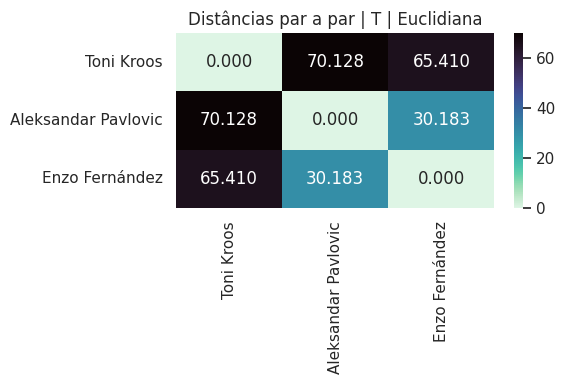

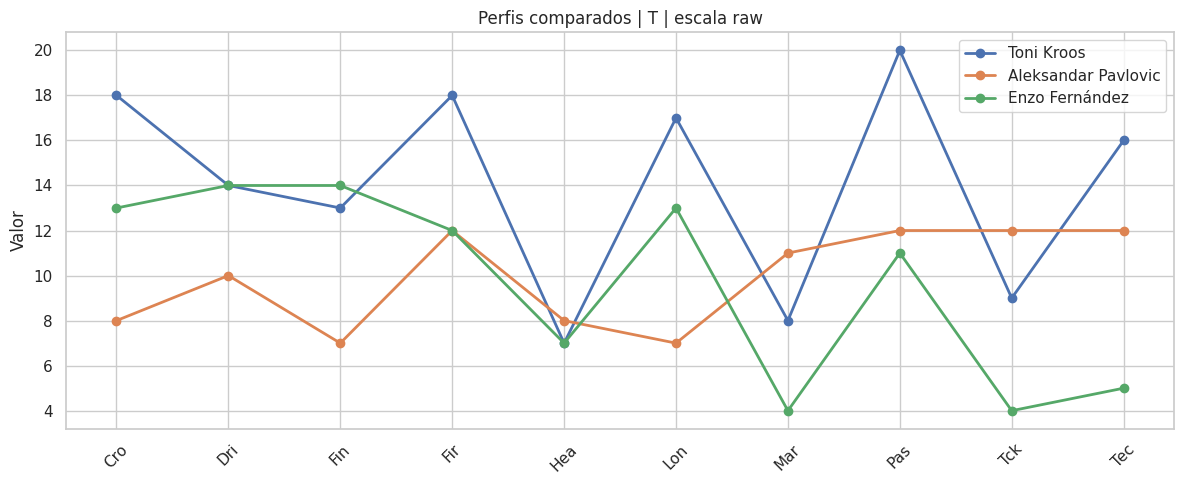

In [ ]:
PLAYER_NAMES = [
    "Toni Kroos",
    "Aleksandar Pavlovic",
    "Enzo Fernández"
 ]
FEATURE_SET_KEY = DEFAULT_FEATURE_SET_KEY
METRIC = DEFAULT_METRIC

if model_selection_summary:
    display(pd.DataFrame([model_selection_summary]))

selected_players = resolve_players(PLAYER_NAMES, minimum=2)
distance_df, profile_df = compare_selected_players(
    player_names=PLAYER_NAMES,
    feature_set_key=FEATURE_SET_KEY,
    metric=METRIC,
)

display(
    selected_players[["UID", "player_name", "club", "position", "age", "primary_role"]]
    .rename(columns={"UID": "uid"})
    .reset_index(drop=True)
 )
display(distance_df.round(4))
display(profile_df)

plt.figure(figsize=(6, 4))
sns.heatmap(distance_df, annot=True, fmt=".3f", cmap="mako_r")
plt.title(
    f"Distâncias par a par | {FEATURE_ALIASES[FEATURE_SET_KEY]} | {METRIC_LABELS[METRIC]}"
 )
plt.tight_layout()
plt.show()

plot_selected_profiles(PLAYER_NAMES, feature_set_key=FEATURE_SET_KEY, scale_suffix="raw")

## 4. Vizinhos similares por jogador

Aqui a análise muda de comparação fechada entre nomes para recuperação nominal de candidatos similares. Isso permite inspecionar cada jogador como consulta e verificar se os vizinhos retornados fazem sentido sob a mesma configuração do bloco anterior.

In [5]:
TOP_K = 8
SAME_ROLE_ONLY = True

for player_name in PLAYER_NAMES:
    print()
    print(f"Consulta: {player_name}")
    neighbor_df = get_neighbors(
        player_name=player_name,
        feature_set_key=FEATURE_SET_KEY,
        metric=METRIC,
        top_k=TOP_K,
        same_role_only=SAME_ROLE_ONLY,
    )
    display(neighbor_df)


Consulta: A.J. Cochran


,uid,distance,player_name,club,position,age,primary_role
0,92102101,0.011334,Vincent Gembalies,MSV Duisburg,D (C),22,DEF
1,19189684,0.017850,Alex Flávio,NaN,D (C),29,DEF
2,52095168,0.019693,Niall Logue,Memphis,D (C),26,DEF
3,28099477,0.022071,Dan Casey,Sacramento,D (C),24,DEF
4,67174736,0.025692,Robert Costa,Sta. Eulalia,D (C),28,DEF
5,52071100,0.025692,Ethan Boyle,Finn Harps,"D/WB (R), DM, M (C)",25,DEF
6,89061927,0.029469,Brunão,Leixões,D (C),25,DEF
7,91017778,0.035858,Niklas Dams,Borussia Dortmund II,"D (C), DM, M (C)",32,DEF



Consulta: A.J. DeLaGarza


,uid,distance,player_name,club,position,age,primary_role
0,2002077815,0.062884,Alec Wright,Louisiana Krewe,D (RC),19,DEF
1,5704171,0.083068,Choi Hyo-Jin,Jeonnam,"D (RL), WB/M (R)",38,DEF
2,965122,0.097823,Franco Flores,Dep. Madryn,D/WB/M (R),34,DEF
3,2002076879,0.106744,Erik Steinslett,OCSC Academy,D (RL),17,DEF
4,2002076345,0.109002,Gilberto Olvera,San Diego Surf,D (RL),17,DEF
5,37003948,0.123773,Gersom Klok,HHC,D/WB/M/AM (R),31,DEF
6,43591751,0.125345,Andrea Pozzi,Varesina,D/WB (L),19,DEF
7,2002076744,0.138474,Callum Ramírez,Empire United,D (L),15,DEF



Consulta: A.J. Paterson


,uid,distance,player_name,club,position,age,primary_role
0,61077149,0.036530,Lewis Mayo,Kilmarnock,D (C),22,DEF
1,14030875,0.039396,Ricardo Marín,Comercio (Villa Dolores),"D (LC), WB (L)",36,DEF
2,91100605,0.044018,Lasse Schlüter,NaN,D/WB/M (L),30,DEF
3,2000024304,0.051252,Ibaider Garriz,Atlético Pamplona B,D (RC),21,DEF
4,72048291,0.053690,Sam Hamilton,New Mexico,"D (C), DM, M (C)",26,DEF
5,19225502,0.054995,Maurício,Marcílio Dias,"D (C), DM",28,DEF
6,62123724,0.056543,Ilija Martinović,Paxtakor,D (C),28,DEF
7,15041534,0.061837,Aaron Calver,Gwangju,D (RC),26,DEF


## 5. Sensibilidade à métrica

Quando a mesma consulta muda pouco entre Euclidiana, Cosseno e Pearson, há maior robustez na leitura qualitativa. Quando muda muito, isso sugere que o perfil do jogador depende fortemente da noção de similaridade escolhida.

In [6]:
ANCHOR_PLAYER = PLAYER_NAMES[0]

metric_comparison_df = compare_neighbor_sets(
    player_name=ANCHOR_PLAYER,
    feature_set_key=FEATURE_SET_KEY,
    metrics=("euclidean", "cosine", "pearson"),
    top_k=5,
    same_role_only=SAME_ROLE_ONLY,
 )

display(metric_comparison_df)

if len(PLAYER_NAMES) >= 2:
    pair_diff_df = summarize_pair_differences(
        PLAYER_NAMES[0],
        PLAYER_NAMES[1],
        feature_set_key=FEATURE_SET_KEY,
        top_n=min(8, len(feature_sets[FEATURE_SET_KEY])),
    )
    display(pair_diff_df)

,metric,uid,distance,player_name,club,position,age,primary_role
0,Euclidiana,28099477,0.251263,Dan Casey,Sacramento,D (C),24,DEF
1,Euclidiana,92102101,0.302286,Vincent Gembalies,MSV Duisburg,D (C),22,DEF
2,Euclidiana,89061927,0.368014,Brunão,Leixões,D (C),25,DEF
3,Euclidiana,52095168,0.458941,Niall Logue,Memphis,D (C),26,DEF
4,Euclidiana,50043042,0.467496,Achille Robin,Tacoma,"D (C), DM, M (C)",25,DEF
5,Cosseno,92102101,0.011334,Vincent Gembalies,MSV Duisburg,D (C),22,DEF
6,Cosseno,19189684,0.017850,Alex Flávio,NaN,D (C),29,DEF
7,Cosseno,52095168,0.019693,Niall Logue,Memphis,D (C),26,DEF
8,Cosseno,28099477,0.022071,Dan Casey,Sacramento,D (C),24,DEF
9,Cosseno,67174736,0.025692,Robert Costa,Sta. Eulalia,D (C),28,DEF


,attribute,A.J. Cochran,A.J. DeLaGarza,abs_diff
0,Jum,14,8,6
1,Str,14,9,5
2,Bal,10,14,4
3,Sta,13,10,3
4,Nat.1,11,13,2
5,Agi,9,11,2
6,Acc,11,11,0
7,Pac,11,11,0
